![Henry Logo](https://www.soyhenry.com/_next/static/media/HenryLogo.bb57fd6f.svg)



# M3L1 E03 - ReAct: Clima y Cálculo (Resolution)
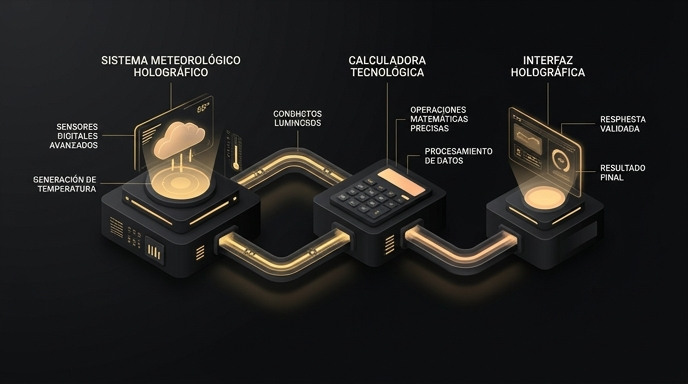

## Qué es este ejercicio

Este notebook trabaja un ejemplo autocontenido: consultar clima, usar esa observación y hacer un cálculo con una segunda herramienta.

El objetivo es practicar el patrón ReAct de forma simple: primero observar, después calcular y recién al final responder.

## Consulta del usuario

> "¿Cuál es el clima más reciente en París y cuánto es 5 veces esa temperatura en Celsius?"


## Mapa del patrón ReAct aplicado a este ejemplo

Idea central del patrón:

```text
[Thought] Necesito conocer la temperatura actual de París.
[Action]  weather_tool("Paris")
[Observation] 21°C

[Thought] Ahora debo multiplicar 21 por 5.
[Action]  calculator_tool(21, 5)
[Observation] 105

[Final Answer] La temperatura en París es 21°C y cinco veces esa temperatura es 105°C.
```

Cada etiqueta tiene una función precisa:

| Etiqueta | Función |
|---|---|
| `[Thought]` | El agente razona sobre qué necesita. |
| `[Action]` | El agente elige una tool y la ejecuta. |
| `[Observation]` | El agente lee el resultado de la tool. |
| `[Final Answer]` | El agente responde usando las observaciones. |

Ventaja clave: si imprimir estas etiquetas mientras corre el agente, obtenés un **trace auditable** que podés revisar y depurar.


## Paso 1 - Herramientas disponibles

Definimos dos herramientas.

### `weather_tool`

En producción llamaría a una API real de clima. Acá usamos un mock con datos fijos para que el ejercicio sea ejecutable sin API key.

### `calculator_tool`

En lugar de `eval()` (peligroso), usamos una versión segura con operaciones explícitas.

La seguridad en herramientas explica por qué `eval` es peligroso:

> Si un usuario malicioso envía `__import__("os").system("rm -rf /")`, podría ejecutar comandos peligrosos.

La versión segura acepta solo operaciones conocidas: multiplicar, sumar, restar, dividir.


In [ ]:
WEATHER_DB = {"Paris": 21, "London": 15, "Berlin": 18, "Buenos Aires": 25}


def weather_tool(ciudad: str) -> dict:
    """
    Tool: devuelve la temperatura actual de una ciudad.
    Retorna dict con success, temperatura y unidad.
    """
    temperatura = WEATHER_DB.get(ciudad)
    if temperatura is None:
        return {"success": False, "error": f"Ciudad no encontrada: {ciudad}"}
    return {"success": True, "ciudad": ciudad, "temperatura_c": temperatura, "unidad": "Celsius"}


def calculator_tool(operacion: str, a: float, b: float) -> dict:
    """
    Tool: calculadora segura con operaciones explicitas.
    Operaciones soportadas: multiplicar, sumar, restar, dividir.
    """
    if operacion == "multiplicar":
        return {"success": True, "resultado": a * b}
    if operacion == "sumar":
        return {"success": True, "resultado": a + b}
    if operacion == "restar":
        return {"success": True, "resultado": a - b}
    if operacion == "dividir":
        if b == 0:
            return {"success": False, "error": "No se puede dividir por cero"}
        return {"success": True, "resultado": a / b}
    return {"success": False, "error": f"Operacion no soportada: {operacion}"}


print("weather_tool('Paris')       ->", weather_tool("Paris"))
print("calculator_tool('multiplicar', 21, 5) ->", calculator_tool("multiplicar", 21, 5))
print("weather_tool('Tokio')       ->", weather_tool("Tokio"))


## Paso 2 - Funciones de logging del trace

Una buena práctica de la trazabilidad del agente es **etiquetar cada paso explícitamente**.


In [ ]:
def thought(mensaje: str):
    print(f"[Thought] {mensaje}")


def action(nombre_tool: str, *args):
    args_str = ", ".join(str(a) for a in args)
    print(f"[Action] {nombre_tool}({args_str})")


def observation(resultado):
    print(f"[Observation] {resultado}")


def final_answer(respuesta: str):
    print(f"[Final Answer] {respuesta}")
    return respuesta


## Paso 3 - Agente ReAct implementado


In [ ]:
def agente_react(consulta: str, ciudad: str) -> str:
    """
    Agente ReAct minimo: clima + calculo.
    Ejecuta un ejemplo autocontenido de ReAct con una tool de clima y una tool de calculo.
    """
    print(f"[Consulta] {consulta}")
    print()

    thought(f"Necesito conocer la temperatura actual de {ciudad}.")
    action("weather_tool", ciudad)
    resultado_clima = weather_tool(ciudad)
    observation(resultado_clima)

    if not resultado_clima["success"]:
        return f"No pude obtener la temperatura de {ciudad}. No voy a estimar el resultado."

    temperatura = resultado_clima["temperatura_c"]

    thought(f"Ahora debo multiplicar {temperatura} por 5.")
    action("calculator_tool", "multiplicar", temperatura, 5)
    resultado_calculo = calculator_tool("multiplicar", temperatura, 5)
    observation(resultado_calculo)

    resultado = resultado_calculo["resultado"]

    return final_answer(
        f"La temperatura en {ciudad} es {temperatura}°C "
        f"y cinco veces esa temperatura es {resultado}°C."
    )


## Paso 4 - Ejecutar el agente


In [ ]:
CONSULTA = "¿Cuál es el clima en París y cuánto es 5 veces esa temperatura?"
respuesta = agente_react(CONSULTA, "Paris")
print()
print(f"Respuesta del agente: {respuesta}")


## Paso 5 - Verificar el comportamiento ante fallo de tool


In [ ]:
print("--- Caso: ciudad desconocida ---")
respuesta_fallo = agente_react("¿Cuál es el clima en Tokio?", "Tokio")
print()
print(f"Respuesta del agente: {respuesta_fallo}")


## Paso 6 - Checks automáticos


In [ ]:
def run_checks():
    respuesta_paris = agente_react("¿Cuál es el clima en París y cuánto es 5 veces?", "Paris")
    assert respuesta_paris is not None
    assert "21" in respuesta_paris
    assert "105" in respuesta_paris

    respuesta_fallo = agente_react("¿Cuál es el clima en Tokio?", "Tokio")
    assert respuesta_fallo is not None
    assert "21" not in respuesta_fallo
    assert "105" not in respuesta_fallo

    print("M3L1 E03 Resolution checks passed")


run_checks()


### Cierre

Este notebook termina cuando el agente puede explicar su respuesta a partir de las observaciones generadas por sus herramientas.
